In [60]:
from sentence_transformers import util
from sklearn.metrics.pairwise import cosine_distances
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import copy


In [54]:
# Constants
PROMOTE_THRESHOLD = 0.2   # very similar → promote directly
REVIEW_THRESHOLD = 0.35   # borderline → manual review

In [ ]:
# Load the data
cq_path = "competency_questions_output/clustered_CQs_with_embeddings.json"
with open(cq_path, "r", encoding="utf-8") as f:
    data = json.load(f)
noise_cl = data["Cluster -1"]

num_cq = sum(len(v) for v in data.values())
num_noise = len(noise_cl)
print(f"There are {num_cq} CQs, of them {num_noise} are noise. Thats {num_noise/num_cq:.2%} of all CQs.")

# Extract embeddings
noise_embeddings = []
for cq in noise_cl:
    noise_embeddings.append(cq["embedding"])

core_embeddings = []
for cluster_name, cqs in data.items():
    if cluster_name == "Cluster -1":
        continue
    for cq in cqs:
        core_embeddings.append(cq["embedding"])

noise_embeddings = np.array(noise_embeddings)
core_embeddings = np.array(core_embeddings)

# Map core index to cluster name
core_index_to_cluster = {}
current_index = 0
for cluster_name, cqs in data.items():
    if cluster_name == "Cluster -1":
        continue
    for _ in cqs:
        core_index_to_cluster[current_index] = cluster_name
        current_index += 1


There are 1709 CQs, of them 522 are noise. Thats 30.54% of all CQs.


Compute d_min for each noise CQ
This tells us how close each noise CQ is to any clustered CQ.

In [56]:
dist_matrix = cosine_distances(noise_embeddings, core_embeddings)

# Get the minimum distance and index of closest core for each noise CQ
d_min = dist_matrix.min(axis=1)
nearest_core_index = dist_matrix.argmin(axis=1)

triaged = {"promote": [], "review": [], "leave": []}

for i, cq in enumerate(noise_cl):
    distance = d_min[i]
    nearest_idx = nearest_core_index[i]
    nearest_cluster = core_index_to_cluster[nearest_idx]

    if distance <= PROMOTE_THRESHOLD:
        triaged["promote"].append({
            "cq": cq["cq"],
            "embedding": cq["embedding"],
            "d_min": float(distance),
            "nearest_core_index": int(nearest_idx),
            "nearest_cluster": nearest_cluster
        })
    elif distance <= REVIEW_THRESHOLD:
        triaged["review"].append({
            "cq": cq["cq"],
            "embedding": cq["embedding"],
            "d_min": float(distance),
            "nearest_core_index": int(nearest_idx),
            "nearest_cluster": nearest_cluster
        })
    else:
        triaged["leave"].append({
            "cq": cq["cq"],
            "embedding": cq["embedding"],
            "d_min": float(distance),
            "nearest_core_index": int(nearest_idx),
            "nearest_cluster": nearest_cluster
        })


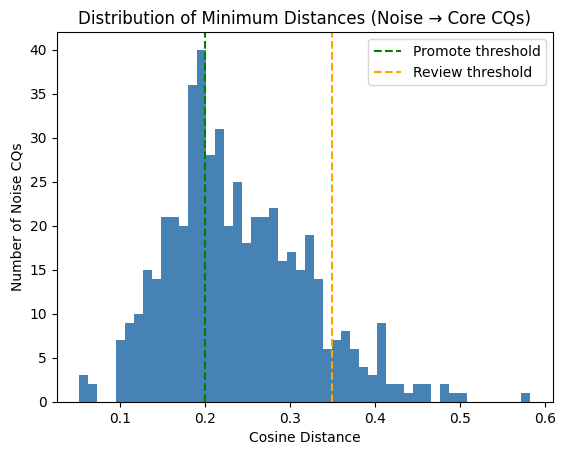

In [ ]:
# Plot triaged data
plt.hist(d_min, bins=50, color="steelblue")
plt.title("Distribution of Minimum Distances (Noise → Core CQs)")
plt.xlabel("Cosine Distance")
plt.ylabel("Number of Noise CQs")
plt.axvline(PROMOTE_THRESHOLD, color='green', linestyle='--', label='Promote threshold')
plt.axvline(REVIEW_THRESHOLD, color='orange', linestyle='--', label='Review threshold')
plt.legend()
plt.show()

In [ ]:
# Save the triaged data
with open("competency_questions_output/noise_triage.json", "w", encoding="utf-8") as f:
    json.dump(triaged, f, ensure_ascii=False, indent=2)


In [ ]:
# Step 1: Copy all clusters except "Cluster -1"
updated_data = {k: copy.deepcopy(v) for k, v in data.items() if k != "Cluster -1"}

# Step 2: Add promoted and review noise CQs to their nearest clusters
for tag in ["promote", "review"]:
    for item in triaged[tag]:
        cluster_name = item["nearest_cluster"]
        cq_entry = {
            "cq": item["cq"],
            "embedding": item["embedding"],
            "from_noise": tag,
            "d_min": item["d_min"]
        }
        updated_data[cluster_name].append(cq_entry)

# Step 3: Create new "Cluster -1" with only the "leave" items
updated_data["Cluster -1"] = [
    {
        "cq": item["cq"],
        "embedding": item["embedding"],
        "from_noise": "leave",
        "d_min": item["d_min"]
    }
    for item in triaged["leave"]
]

ordered_data = dict(sorted(
    updated_data.items(),
    key=lambda x: (x[0] != "Cluster -1", int(x[0].split()[-1]) if x[0].startswith("Cluster ") and x[0] != "Cluster -1" else float('inf'))
))

# Step 4: Save the updated clusters
with open("competency_questions_output/clustered_CQs_with_promoted_and_reviewed_noise.json", "w", encoding="utf-8") as f:
    json.dump(ordered_data, f, ensure_ascii=False, indent=2)